/opt/conda/envs/py310-scoob-env/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
INFO:purepyindi2.transports:Connected to localhost:7624


Could not import deepdish!
Could not import ray. Parallelized model unavailble.


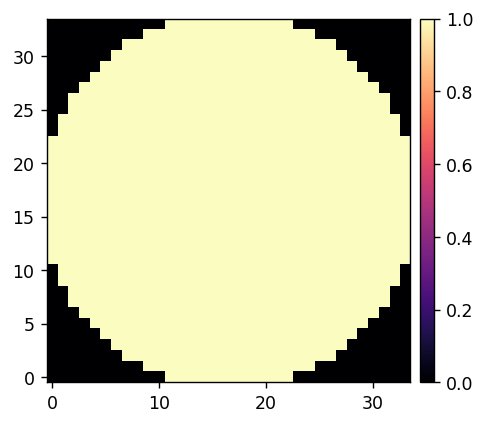

In [1]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime


import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoobscc


from scoobscc.math_module import xp, xcipy, ensure_np_array
from scoobscc import utils, telem, dm
from scoobscc import scc
import scoobscc.scoob_interface as scoobi

import scoobpy


from magpyx.utils import ImageStream

import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307 / 2 # divide by 2 for bin 1 

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

%load_ext autoreload
%autoreload 2

## Directory

In [2]:
today = int(datetime.today().strftime('%Y%m%d'))
data_path = str(scoobscc.path)[:-9] + '/data_exp'

exp_path = data_path + f'/{today}_pointing'
telem.make_dir(exp_path)

Directory '/home/derbyk/src/scoob-scc/data_exp/20250627_pointing' created successfully.


## Init Cam

In [3]:
camsci_channel = 'camsci'
dm_ho_channel = 'dm00disp03'

xc, yc = (5680, 2615)
ncamsci = 512

scoobi.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel, bin_mode=1)
time.sleep(1)
scoobi.set_cam_exp_time(1e-3, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_gain(120, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_blacklevel(4, client0, cam_name=camsci_channel)
time.sleep(1)

camsci_stream = ImageStream(camsci_channel)
dm_ho_stream = ImageStream(dm_ho_channel)

Set camsci ROI.
Set the camsci exposure time to 1.00e-03s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 4.0


## Dark Calib

In [4]:
scoobi.move_block_in(client0)

Set the camsci exposure time to 1.00e-03s
{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 0.0}


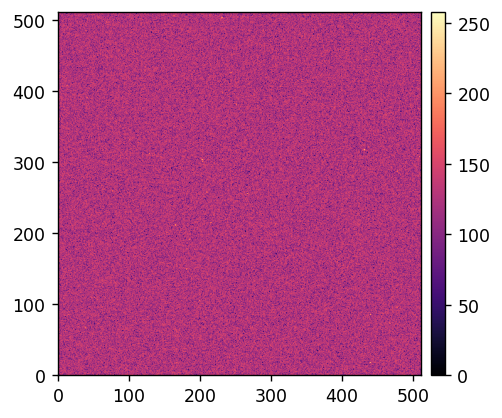

In [7]:
texp = 1e-3

scoobi.set_cam_exp_time(texp, client0, cam_name=camsci_channel)
time.sleep(3)

dark_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
dark_params.update({'atten':0.0})
dark_frame = scoobi.snap(camsci_stream, 100)

print(dark_params)
utils.imshow([dark_frame])

hdu = fits.PrimaryHDU(data=dark_frame)
hdr = hdu.header
hdr['TEXP'] = dark_params['texp']
hdr['GAIN'] = dark_params['gain']
hdr['ATTEN'] = dark_params['atten']

hdu.writeto(exp_path + f'/dark_frame_{texp:.0e}s.fits', overwrite=True)

In [8]:
scoobi.move_block_out(client0)

## Move PSF

In [66]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_x_pos', val=-1)

In [71]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_y_pos', val=-1)

## Reference PSF

In [27]:
scoobi.set_fib_atten(35, client)

Set the fiber attenuation to 35.0


{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 35.0, 'Iref': 27957.2}


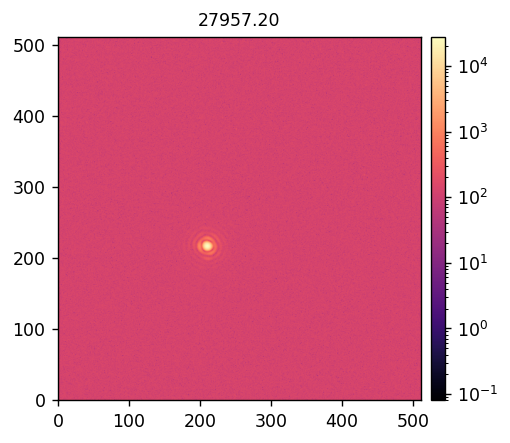

In [28]:
ref_psf = scoobi.snap(camsci_stream, 200)
Iref = np.max(ref_psf)

ref_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
ref_params.update({'atten':35.0})
ref_params.update({'Iref': Iref})

print(ref_params)
utils.imshow([ref_psf], titles=[f'{Iref:.2f}'], norms=[LogNorm()])

In [29]:
hdu = fits.PrimaryHDU(data=ref_psf)
hdr = hdu.header
hdr['TEXP'] = ref_params['texp']
hdr['GAIN'] = ref_params['gain']
hdr['ATTEN'] = ref_params['atten']

hdu.writeto(exp_path + '/ref_psf.fits', overwrite=True)

scoobi.set_fib_atten(0, client)

Set the fiber attenuation to 0.0


## Waffle

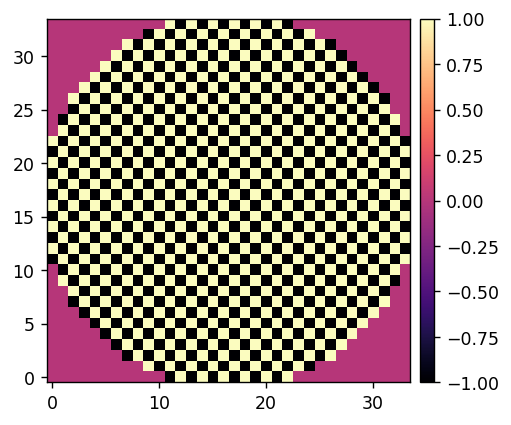

In [72]:
waffle_command = ensure_np_array(dm.make_fourier_command(x_cpa=17, y_cpa=17)) * dm_mask
utils.imshow([waffle_command])

{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 0.0}


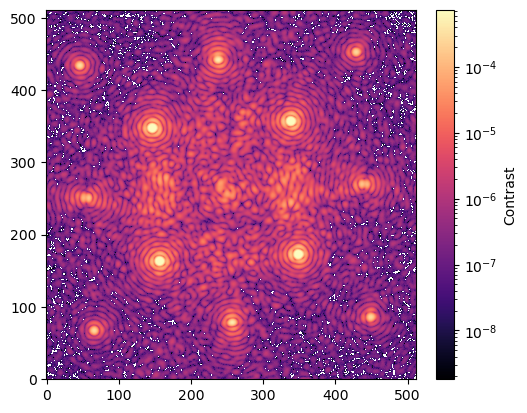

In [73]:
im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})

scoobi.set_dm(dm_ho_stream, 50e-9 * waffle_command)
waffle_im = scoobi.snap(camsci_stream, 100, ensure_np_array(dark_frame), im_params, ref_params)

print(im_params)
plt.figure()
plt.imshow(waffle_im, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')

Centroids:
 [[156.8841577  162.75606823]
 [146.86880068 346.99886583]
 [338.50156211 356.48048227]
 [348.82421506 172.16084934]
 [156.8841577  162.75606823]]


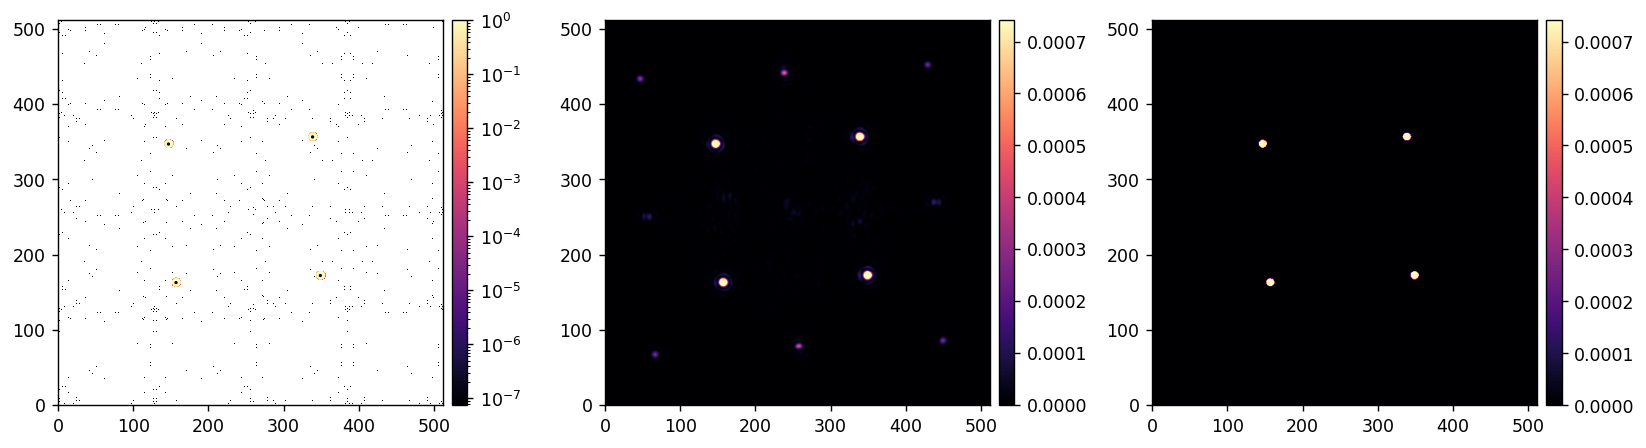

Angle:  87.01132507168622
Measured center in X:  247.74181453816087
Measured center in Y:  259.6704933041188
Required shift in X:  8.0
Required shift in Y:  -4.0


In [ ]:
xpos, ypos, angle = utils.measure_waffle_center_and_angle(xp.array(waffle_im), camsci_pxscl_lamDc, im_thresh=5e-4, r_thresh_min=16, r_thresh_max=25)

Saved data to:  /home/derbyk/src/scoob-scc/data_exp/20250627_pointing/control_mask.fits


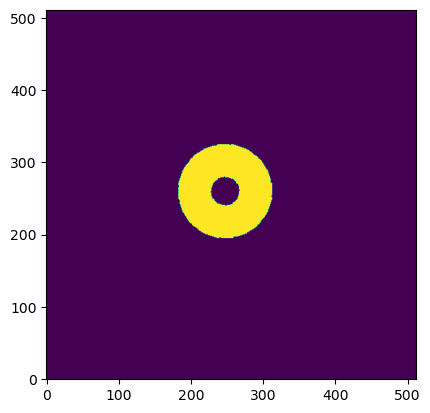

In [96]:
iwa = 3
owa = 10
rotation = angle - 90

control_mask = ensure_np_array( utils.create_annular_mask(
    ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    x_shift=-xpos,
    y_shift=-ypos,
    rotation=rotation,
))

plt.imshow(control_mask)

utils.save_fits(exp_path + '/control_mask.fits', data=xp.asnumpy(control_mask).astype('int'))

## Loop

In [83]:
iterations = 300
delay = 6

im_cube = []
centroid_cube = []
humidity_vals = []


for i in range(iterations):
    print(f'Measurement {i + 1:.0f} / {iterations:.0f}')
    waffle_im = scoobi.snap(camsci_stream, 100, ensure_np_array(dark_frame), im_params, ref_params)
    centroids = utils.get_centroids(xp.array(waffle_im), camsci_pxscl_lamDc, im_thresh=5e-4, r_thresh_min=16, r_thresh_max=25)

    im_cube.append(waffle_im)
    centroid_cube.append(centroids)
    humidity_vals.append(client['rhkilo.humidity.current'])

    time.sleep(delay)

Measurement 1 / 300
Measurement 2 / 300
Measurement 3 / 300
Measurement 4 / 300
Measurement 5 / 300
Measurement 6 / 300
Measurement 7 / 300
Measurement 8 / 300
Measurement 9 / 300
Measurement 10 / 300
Measurement 11 / 300
Measurement 12 / 300
Measurement 13 / 300
Measurement 14 / 300
Measurement 15 / 300
Measurement 16 / 300
Measurement 17 / 300
Measurement 18 / 300
Measurement 19 / 300
Measurement 20 / 300
Measurement 21 / 300
Measurement 22 / 300
Measurement 23 / 300
Measurement 24 / 300
Measurement 25 / 300
Measurement 26 / 300
Measurement 27 / 300
Measurement 28 / 300
Measurement 29 / 300
Measurement 30 / 300
Measurement 31 / 300
Measurement 32 / 300
Measurement 33 / 300
Measurement 34 / 300
Measurement 35 / 300
Measurement 36 / 300
Measurement 37 / 300
Measurement 38 / 300
Measurement 39 / 300
Measurement 40 / 300
Measurement 41 / 300
Measurement 42 / 300
Measurement 43 / 300
Measurement 44 / 300
Measurement 45 / 300
Measurement 46 / 300
Measurement 47 / 300
Measurement 48 / 300
M

In [92]:
hdu = fits.PrimaryHDU(data=xp.asnumpy(im_cube))
hdu.writeto(exp_path + '/im_cube.fits', overwrite=True)

hdu = fits.PrimaryHDU(data=xp.asnumpy(centroid_cube))
hdu.writeto(exp_path + '/centroid_cube.fits', overwrite=True)

hdu = fits.PrimaryHDU(data=xp.asnumpy(humidity_vals))
hdu.writeto(exp_path + '/humidity_vals.fits', overwrite=True)

In [89]:
scoobi.zero_dm(dm_ho_stream)

## Analysis

In [97]:
images = fits.getdata(exp_path + '/im_cube.fits')
mask = fits.getdata(exp_path + '/control_mask.fits').astype(bool)
centroids = fits.getdata(exp_path + '/centroid_cube.fits')
humidity = fits.getdata(exp_path + '/humidity_vals.fits')

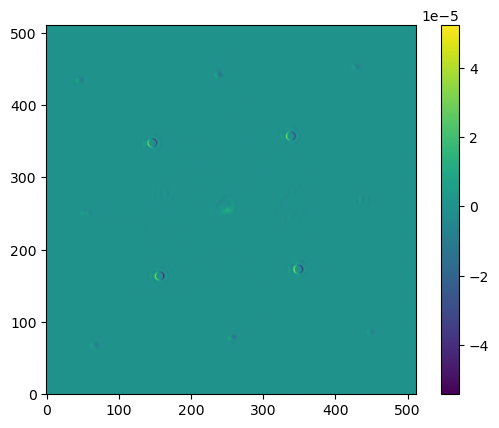

In [102]:
plt.imshow(images[-1] - images[0])
plt.colorbar()

In [119]:
c0 = centroids[0]
xshifts = []
yshifts = []

for c in centroids:

    xdiffs = [c[0, 0] - c0[0, 0],
          c[1, 0] - c0[1, 0],
          c[2, 0] - c0[2, 0],
          c[3, 0] - c0[3, 0],]
    xshift = np.mean(np.asarray(xdiffs))
    xshifts.append(xshift)

    ydiffs = [c[0, 1] - c0[0, 1],
            c[1, 1] - c0[1, 1],
            c[2, 1] - c0[2, 1],
            c[3, 1] - c0[3, 1],]
    yshift = np.mean(np.asarray(ydiffs))
    yshifts.append(yshift)

(0.0, 3000.0)

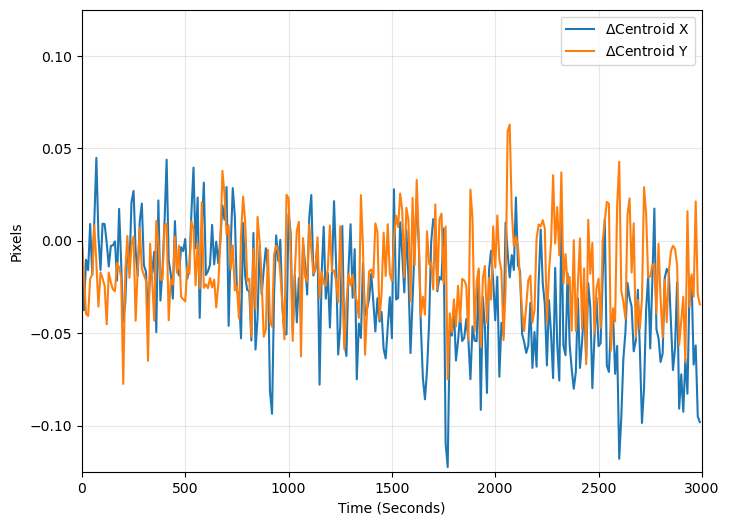

In [126]:
plt.figure(figsize=(8, 6))
plt.plot(np.arange(300) * 10, xshifts, label='$\Delta$Centroid X')
plt.plot(np.arange(300) * 10, yshifts, label='$\Delta$Centroid Y')
plt.legend()
plt.grid(alpha=0.3)
plt.ylabel('Pixels')
plt.xlabel('Time (Seconds)')
plt.ylim([-0.125, 0.125])
plt.xlim([0, 3000])

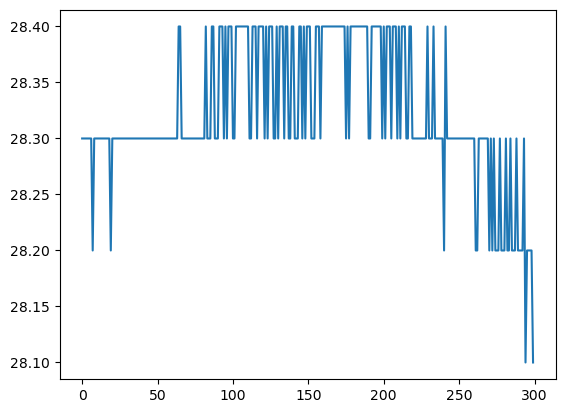

In [127]:
plt.plot(humidity_vals)